# Задача 1. Модель: полносвязная сеть с явным взаимодействием веток

Четвёртый ноутбук конвейера (`EDA_1` → `preprocess.py` → `task1.ipynb` → **этот**).
Вход — артефакты `task1.ipynb`:

- `data/processed/task1_embed_inputs.parquet` — индексы категорий (паддинг до 10) + 15 масштабированных числовых признаков;
- `data/processed/task1_features.parquet` — циклические временные признаки;
- `data/processed/task1_dataset.parquet` — ключи, даты и сырые агрегаты (для prior-признаков, сегментов и бейзлайнов);
- `artifacts/task1_vocab_*.json` — словари индексов (fit только на train).

Предсказываем оценку **`stars` (1–5)**, которую пользователь поставит заведению, по табличным
признакам пользователя и заведения. ID юзера и заведения в основной модели **не используются** —
обоснование ниже; эмбеддинг заведения проверяется отдельно в абляции (раздел 8).

## 1. Обоснование архитектуры

### 1.1. Что диктуют данные

Факты о срезе (посчитаны в `EDA`/этом конвейере; сегменты пересчитываются в разделе 10):

| Факт | Следствие для архитектуры |
|---|---|
| Временной сплит 70/15/15: train до 2019-01, test после 2020-04 (ковидный период) | Оцениваемся на будущем; агрегатные признаки не подсматривают вперёд |
| В test **62.6% строк — от юзеров, которых нет в train**; медиана отзывов на юзера = 1 | ID-эмбеддинг юзера бесполезен: на большинстве test-строк это был бы случайный OOV-вектор |
| В test 20% строк — от заведений, которых нет в train | Даже эмбеддинг заведения промахнётся на каждой пятой строке |
| Дрейф таргета: train — 43% пятёрок и 14% единиц, test — 53% и 22% (поляризация) | Test объективно труднее; метрики сравниваем только с бейзлайнами на том же сплите |
| `categories` заведения — мульти-лейбл (несколько кухонь) | Нужен пулинг эмбеддингов, а не one-hot |

Главное решение: **модель контентная — только признаки, без ID-эмбеддингов**. Это стандартная
рекомендация для холодного старта: без истории взаимодействий работают контентные/гибридные модели
на атрибутах ([обзор cold-start, 2025](https://arxiv.org/pdf/2501.01945),
[Wikipedia: Cold start](https://en.wikipedia.org/wiki/Cold_start_(recommender_systems))).

### 1.2. Бейзлайны — планка качества

Раздел 5 считает на этом же сплите: глобальное среднее, среднюю заведения, среднюю юзера,
bias-модель `user_avg + biz_avg − μ` (классический сильный бейзлайн со времён Netflix Prize —
[Koren, Bell, Volinsky, 2009](https://datajobs.com/data-science-repo/Recommender-Systems-%5BNetflix%5D.pdf))
и Ridge-регрессию по всем числовым признакам. Предварительный анализ показал: Ridge **не лучше**
bias-модели (~1.12 RMSE) — линейная комбинация признаков не добавляет ничего к сумме двух средних.
Значит, добавленная стоимость нейросети может прийти только из **нелинейностей, взаимодействий
признаков и более информативных признаков** — архитектура и фичи строятся вокруг этого.
Сеть оправдана, только если бьёт bias-модель.

### 1.3. Четыре вывода из литературы

1. **Категориальные признаки — в обучаемые эмбеддинги** (entity embeddings,
   [Guo & Berkhahn, 2016](https://arxiv.org/abs/1604.06737)): компактнее one-hot и лучше
   генерализуют на разреженных данных. Мульти-лейбл `categories` кодируем `EmbeddingBag`
   (среднее эмбеддингов кухонь заведения) — так же обрабатываются pooled sparse-поля в DLRM.
   Эвристика размерности fastai `1.6·n^0.56` ([docs.fast.ai](https://docs.fast.ai/tabular.model.html);
   в `task1.ipynb` используется вариант с капом 50) для нашего словаря из ~424 категорий дала бы ~47;
   стартуем с консервативных 16, увеличение до 32 проверяется в разделе 9.
2. **MLP плохо выучивает скалярное произведение из конкатенации** — главный результат
   [Rendle et al., RecSys 2020](https://dl.acm.org/doi/10.1145/3383313.3412488): правильно
   настроенный dot product обходит «нейросетевую похожесть» NCF, а выучить его MLP-ом нетривиально.
   Поэтому мультипликативные взаимодействия подаём сети **явно**: `u·b` и `u⊙b`. Вклад проверяем
   честно: при фиксированном лоссе и на нескольких сидах (раздел 7.2).
3. **Гибрид «deep + явные взаимодействия» — индустриальный стандарт**: Wide&Deep → DeepFM → DCN
   ([обзор архитектур](https://aman.ai/recsys/architectures/), [DCN](https://arxiv.org/pdf/1708.05123)).
   Наша компоновка повторяет [DLRM](https://arxiv.org/abs/1906.00091): нижние MLP для dense-признаков,
   эмбеддинги для sparse, слой попарных взаимодействий, верхний MLP. Cross-слои
   [DCN-v2](https://arxiv.org/abs/2008.13535) проверяются отдельно в разделе 9.
4. **Cold-start лечится контентными признаками** (см. 1.1) — юзер описан агрегатами
   (`average_stars`, `review_count`, `fans`, ...), заведение — агрегатами и категориями.

### 1.4. Time-aware prior-признаки

Статические агрегаты (`average_stars`, `biz_avg_stars`) усреднены по **всей** истории — они
сглаживают динамику и несут мягкую утечку (включают будущие отзывы). Добавляем их «честных
близнецов», посчитанных **строго по прошлому** относительно даты каждого отзыва
(expanding-статистики со сдвигом):

- `u_prior_mean`, `u_cnt`, `u_days_prev`, `u_has_hist` — средняя оценка, число отзывов и давность
  последнего отзыва юзера НА МОМЕНТ текущего отзыва;
- `b_prior_mean`, `b_cnt`, `b_days_prev`, `b_has_hist` — то же для заведения.

Идея, что у baseline-предикторов есть временная динамика и её учёт даёт основной прирост,
восходит к Netflix Prize ([Koren, «Collaborative Filtering with Temporal Dynamics», KDD 2009](https://dl.acm.org/doi/10.1145/1557019.1557072)).
Утечки нет по построению — для каждой строки используются только более ранние отзывы; в разделе 3
это дополнительно проверяется ручной сверкой. Абляция (раздел 7.1) показывает, что эти
8 признаков дают наибольший прирост качества; гео-дистанция до «центра масс» прошлых отзывов
юзера и ценовая близость прироста не дали и в финальную модель не вошли.

### 1.5. Архитектура

```
Юзер: 9 + 4 prior ──────────────► MLP ─► u ─┐
                                            ├─► [u ⊕ b ⊕ u⊙b ⊕ u·b ⊕ контекст]
Заведение: 5 + 4 prior ─┐                   │        │
город one-hot (4) ──────┼► concat ─► MLP ─► b        ▼
категории ≤10 ──► EmbeddingBag(mean) ─┘        верхний MLP ─► голова
                                               (BatchNorm, ReLU, Dropout)
Контекст: user_avg_minus_biz + время sin/cos (7)
```

- `u⊙b` — поэлементное произведение, `u·b` — скалярное: готовые мультипликативные члены
  «строгость юзера × качество места» (вывод 2 из 1.3).
- **Голова** — два варианта (сравниваются в разделе 9): регрессия одним нейроном и
  классификация на 5 классов с decode-ожиданием (см. 1.7).
- Бюджет параметров печатается в разделе 6; обучается на MPS за десятки секунд.
- Для сравнения обучается **плоский MLP** на той же конкатенации (256→128→64) — с обоими
  лоссами, чтобы вклад архитектуры измерялся при фиксированном лоссе.

### 1.6. Отвергнутые альтернативы

- **MF / NCF (ID-only)** — коллаборативная фильтрация не работает при 62.6% холодных юзеров в test.
- **ID-эмбеддинги в основной модели** — юзерный мёртв (медиана 1 отзыв), заведенческий проверяем
  абляцией в разделе 8 при фиксированном лоссе.
- **TabTransformer / AutoInt** — самовнимание окупается на десятках категориальных полей и
  миллиардах примеров; у нас 3 категориальных поля и 465k строк.
- **Two-tower с чистым dot product** — нужен для retrieval по миллионам айтемов; при 17.5k заведений
  можно скорить все напрямую, жертвовать кросс-признаками незачем.
- **Больше данных** — кривая обучения (5% → 100% train: test RMSE 1.113 → 1.102) вышла на плато:
  узкое место — информативность признаков, а не объём. Поэтому усилие вложено в prior-признаки.

### 1.7. Целевая переменная, голова и лосс

Таргет — `stars` (1–5). Базовая голова — **регрессия** одним нейроном (клип в [1, 5] на
инференсе); сравниваем два лосса: **MSE** (точно соответствует метрике RMSE) и **Huber/SmoothL1**
(β=1; test поляризован — Huber не даёт большим неизбежным промахам на единицах доминировать
в градиенте; ожидаемо выигрывает по MAE, проигрывая по RMSE).

Альтернативная голова — **классификация с decode-ожиданием**: 5 логитов, CrossEntropy,
предсказание `ŷ = Σ p(k)·k`. Оценки дискретны и бимодальны («1 или 5»), softmax моделирует
всё распределение, а не только среднее; приём известен как DEX
([Rothe, Timofte, Van Gool, ICCV-W 2015](https://www.cv-foundation.org/openaccess/content_iccv_2015_workshops/w11/html/Rothe_DEX_Deep_EXpectation_ICCV_2015_paper.html) —
«регрессия как классификация + softmax expected value», победитель ChaLearn LAP 2015).
Родственное направление — порядковая регрессия [CORAL](https://arxiv.org/abs/1901.07884).

Признак `year` в модель не берём: train заканчивается 2019-м, и экстраполяция года на
ковидный test — источник нестабильности. Циклические `sin/cos` (месяц, день недели, час) берём.

### 1.8. Методологические правила

- Все сравнения «архитектура A против B» и абляции — при **фиксированном лоссе/голове**.
- Лучшая конфигурация выбирается **по val**; test-метрики не печатаются в разделах, где
  принимаются решения, — только один раз в разделе результатов (минимизируем утечку test
  в процесс генерации гипотез).
- Для малых дельт (< 0.01 RMSE) — прогон на **трёх сидах**, репортим среднее и разброс.
- Одиночная модель для сравнения с ансамблем берётся на дефолтном сиде (анти seed-fishing).
- Бейзлайны и сеть оцениваются на одинаковом test с одинаковым клипом [1, 5].

## 2. Импорты и конфигурация

In [1]:
import json
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

_PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(_PROJECT))
from _constants import PROCESSED, ARTIFACTS, ENABLE_ARTIFACTS

SEED = 42
SEEDS_MULTI = [42, 7, 2024]      # мультисид: ключевые сравнения и ансамбль
MAXLEN = 10                      # длина списка категорий (паддинг нулём, как в task1.ipynb)
D_CAT = 16                       # размерность эмбеддинга категории (базовая)
D_BRANCH = 32                    # размерность векторов веток u и b (базовая)
D_BIZ_EMB = 32                   # эмбеддинг заведения (только в абляции)
N_CITY = 4                       # 0 = OOV + 3 города (one-hot)
BATCH = 1024
MAX_EPOCHS = 30
PATIENCE = 5                     # early stopping по val RMSE
LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.2

USER_NUM = ["num_user_review_count", "num_average_stars", "num_user_useful",
            "num_user_funny", "num_user_cool", "num_fans", "num_n_friends",
            "num_n_elite_years", "num_account_age_days"]
BIZ_NUM = ["num_biz_avg_stars", "num_biz_review_count", "num_is_open",
           "num_price_range", "num_price_known"]
CROSS = ["num_user_avg_minus_biz"]
TIME_COLS = ["month_sin", "month_cos", "dow_sin", "dow_cos",
             "hour_sin", "hour_cos", "is_weekend"]
USER_PRIOR = ["u_prior_mean", "u_cnt", "u_days_prev", "u_has_hist"]
BIZ_PRIOR = ["b_prior_mean", "b_cnt", "b_days_prev", "b_has_hist"]
CROSS_PRIOR = ["u_geo_dist", "price_aff"]      # в финальную модель не вошли (раздел 7.1)
CATID_COLS = [f"catid_{i}" for i in range(MAXLEN)]

np.random.seed(SEED)
torch.manual_seed(SEED)
device = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {device}")

torch 2.12.0 | device: mps


## 3. Prior-признаки: статистики строго по прошлому

Сортируем все отзывы по дате и для каждой строки считаем expanding-статистики юзера и заведения
**без текущего отзыва** (cumsum минус текущее значение). Для каждой строки используются только
более ранние отзывы — утечки нет по построению; ниже это проверяется ручной сверкой.
Гео-дистанцию и ценовую близость тоже считаем — они участвуют в абляции раздела 7.1.

In [2]:
ds = pd.read_parquet(PROCESSED / "task1_dataset.parquet",
    columns=["review_id", "user_id", "business_id", "stars", "date",
             "latitude", "longitude", "price_range", "split"])
ds["date"] = pd.to_datetime(ds["date"])
ds = ds.sort_values(["date", "review_id"], kind="mergesort").reset_index(drop=True)

gu = ds.groupby("user_id", sort=False)
ds["u_cnt"] = gu.cumcount()
ds["u_prior_mean"] = np.where(ds.u_cnt > 0, (gu["stars"].cumsum() - ds["stars"]) / ds.u_cnt, np.nan)
ds["u_days_prev"] = gu["date"].diff().dt.total_seconds() / 86400

# гео: расстояние до "центра масс" прошлых отзывов юзера (haversine)
for c in ["latitude", "longitude"]:
    ds[f"u_pc_{c}"] = np.where(ds.u_cnt > 0, (gu[c].cumsum() - ds[c]) / ds.u_cnt, np.nan)
lat1, lon1 = np.radians(ds.latitude), np.radians(ds.longitude)
lat2, lon2 = np.radians(ds.u_pc_latitude), np.radians(ds.u_pc_longitude)
h = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
ds["u_geo_dist"] = 2 * 6371 * np.arcsin(np.sqrt(h))
ds["u_prior_price"] = np.where(ds.u_cnt > 0,
                               (gu["price_range"].cumsum() - ds["price_range"]) / ds.u_cnt, np.nan)
ds["price_aff"] = ds["u_prior_price"] - ds["price_range"]

gb = ds.groupby("business_id", sort=False)
ds["b_cnt"] = gb.cumcount()
ds["b_prior_mean"] = np.where(ds.b_cnt > 0, (gb["stars"].cumsum() - ds["stars"]) / ds.b_cnt, np.nan)
ds["b_days_prev"] = gb["date"].diff().dt.total_seconds() / 86400

# самопроверка отсутствия утечки: пересчёт вручную для юзера с историей
u = ds[ds.u_cnt >= 3]["user_id"].iloc[0]
sub = ds[ds.user_id == u].sort_values("date")
for k in range(1, min(4, len(sub))):
    manual = sub["stars"].iloc[:k].mean()
    assert abs(sub["u_prior_mean"].iloc[k] - manual) < 1e-9, "утечка в u_prior_mean!"
print("[ok] prior-признаки строго по прошлому (ручная сверка прошла)")

[ok] prior-признаки строго по прошлому (ручная сверка прошла)


In [3]:
mu_train = ds.loc[ds.split == "train", "stars"].mean()
ds["u_has_hist"] = (ds.u_cnt > 0).astype(float)
ds["b_has_hist"] = (ds.b_cnt > 0).astype(float)
ds = ds.fillna({"u_prior_mean": mu_train, "b_prior_mean": mu_train,
                "u_days_prev": 3650.0, "b_days_prev": 3650.0,
                "u_geo_dist": 0.0, "price_aff": 0.0})
for c in ["u_cnt", "b_cnt", "u_days_prev", "b_days_prev", "u_geo_dist"]:
    ds[c] = np.log1p(ds[c])

PRIOR_ALL = USER_PRIOR + BIZ_PRIOR + CROSS_PRIOR
prior_scaler = StandardScaler().fit(ds.loc[ds.split == "train", PRIOR_ALL])
ds[PRIOR_ALL] = prior_scaler.transform(ds[PRIOR_ALL])
ds[["review_id"] + PRIOR_ALL].to_parquet(PROCESSED / "task1_prior_feats.parquet", index=False)
joblib.dump(prior_scaler, ARTIFACTS / "task1_prior_scaler.joblib")
print(f"[ok] task1_prior_feats.parquet: {len(PRIOR_ALL)} признаков (scaler fit на train)")

[ok] task1_prior_feats.parquet: 10 признаков (scaler fit на train)


## 4. Данные: сборка единого фрейма и тензоров

Склеиваем всё по `review_id` в **один** DataFrame — таргет, признаки, сырые агрегаты для
бейзлайнов и ключи для сегментов живут в одном порядке строк, позиционные рассинхроны исключены.

In [4]:
emb = pd.read_parquet(PROCESSED / "task1_embed_inputs.parquet")
feats = pd.read_parquet(PROCESSED / "task1_features.parquet",
                        columns=["review_id"] + TIME_COLS)
keys = pd.read_parquet(PROCESSED / "task1_dataset.parquet",
                       columns=["review_id", "user_id", "business_id",
                                "biz_avg_stars", "average_stars"])

df = emb.merge(feats, on="review_id", validate="one_to_one")
df = df.merge(keys, on="review_id", validate="one_to_one")
df = df.merge(ds[["review_id"] + PRIOR_ALL], on="review_id", validate="one_to_one")

cat_vocab = json.load(open(ARTIFACTS / "task1_vocab_categories.json"))
biz_vocab = json.load(open(ARTIFACTS / "task1_vocab_business.json"))
N_CAT_VOCAB = len(cat_vocab) + 1          # +1 под index 0 = <pad>/OOV
N_BIZ_VOCAB = len(biz_vocab) + 1

assert df["city_idx"].max() < N_CITY and df["biz_idx"].max() < N_BIZ_VOCAB
assert not df[USER_NUM + BIZ_NUM + CROSS + TIME_COLS + PRIOR_ALL].isna().any().any()

print(f"строк: {len(df):,} | словарь категорий: {N_CAT_VOCAB} | заведений: {N_BIZ_VOCAB}")
print(df["split"].value_counts().to_dict())

строк: 664,745 | словарь категорий: 424 | заведений: 16340
{'train': 465321, 'val': 99712, 'test': 99712}


In [5]:
def make_tensors(d, ucols, bcols, ccols):
    """Срез DataFrame -> словарь тензоров на device (наборы колонок параметризуются)."""
    t = lambda a, dt: torch.tensor(np.asarray(a), dtype=dt, device=device)
    return {
        "xu":   t(d[ucols].to_numpy(np.float32), torch.float32),
        "xb":   t(d[bcols].to_numpy(np.float32), torch.float32),
        "ctx":  t(d[ccols].to_numpy(np.float32), torch.float32),
        "cats": t(d[CATID_COLS].to_numpy(np.int64), torch.long),
        "city": torch.nn.functional.one_hot(
                    t(d["city_idx"].to_numpy(np.int64), torch.long), N_CITY).float(),
        "biz":  t(d["biz_idx"].to_numpy(np.int64), torch.long),
        "y":    t(d["stars"].to_numpy(np.float32), torch.float32),
    }

splits = {s: df[df["split"] == s] for s in ["train", "val", "test"]}
y_val = splits["val"]["stars"].to_numpy()
y_te = splits["test"]["stars"].to_numpy()

# cold/warm-сегменты test: видел ли train этого юзера / это заведение
train_users = set(splits["train"]["user_id"])
train_biz = set(splits["train"]["business_id"])
warm_user = splits["test"]["user_id"].isin(train_users).to_numpy()
warm_biz = splits["test"]["business_id"].isin(train_biz).to_numpy()
print(f"test: холодных юзеров {1 - warm_user.mean():.1%}, холодных заведений {1 - warm_biz.mean():.1%}")

test: холодных юзеров 62.6%, холодных заведений 20.0%


## 5. Бейзлайны

Планка, которую сеть обязана перебить. Всё считается на тех же train/test, предсказания
клипаются в [1, 5], как и у сети.

In [6]:
from sklearn.linear_model import Ridge

def rmse(y, p):
    return float(np.sqrt(np.mean((y - np.clip(p, 1, 5)) ** 2)))

def mae(y, p):
    return float(np.mean(np.abs(y - np.clip(p, 1, 5))))

mu = splits["train"]["stars"].mean()
te = splits["test"]

NUM_ALL = USER_NUM + BIZ_NUM + CROSS + USER_PRIOR + BIZ_PRIOR
ridge = Ridge(alpha=1.0).fit(splits["train"][NUM_ALL], splits["train"]["stars"])

baselines = {
    "глобальное среднее train": np.full(len(te), mu),
    "средняя заведения (biz_avg_stars)": te["biz_avg_stars"].to_numpy(),
    "средняя юзера (average_stars)": te["average_stars"].to_numpy(),
    "bias: user_avg + biz_avg - mu": (te["average_stars"] + te["biz_avg_stars"] - mu).to_numpy(),
    "Ridge на 23 числовых (с prior)": ridge.predict(te[NUM_ALL]),
}
base_table = pd.DataFrame(
    [{"модель": k, "RMSE": rmse(y_te, p), "MAE": mae(y_te, p)} for k, p in baselines.items()])
bias_rmse = base_table.loc[base_table["модель"].str.startswith("bias"), "RMSE"].item()
p_bias = np.clip(te["average_stars"] + te["biz_avg_stars"] - mu, 1, 5).to_numpy()
print(base_table.round(4).to_string(index=False))

                           модель   RMSE    MAE
         глобальное среднее train 1.6534 1.4697
средняя заведения (biz_avg_stars) 1.4079 1.1119
    средняя юзера (average_stars) 1.2305 0.9172
    bias: user_avg + biz_avg - mu 1.1210 0.7526
   Ridge на 23 числовых (с prior) 1.1185 0.8209


## 6. Модели и обучение

- `FlatMLP` — плоский MLP на полной конкатенации (бейзлайн-архитектура);
- `InteractionMLP` — две ветки + явное взаимодействие (`u·b`, `u⊙b`); параметризуются ёмкость
  (`d_cat`, `d_branch`, `hidden`, `top`), голова (`out`: 1 = регрессия, 5 = классификация)
  и `use_biz_emb` (абляция в разделе 8);
- `DCNv2` — cross-сеть и deep-ствол параллельно над общим входом (проверка в разделе 9).

Все — многослойные полносвязные сети; категории кодируются `EmbeddingBag` (среднее эмбеддингов,
`padding_idx=0` исключается из среднего).

In [7]:
def mlp(dims, p_drop=DROPOUT):
    layers = []
    for i in range(len(dims) - 1):
        layers += [nn.Linear(dims[i], dims[i + 1]), nn.BatchNorm1d(dims[i + 1]),
                   nn.ReLU(), nn.Dropout(p_drop)]
    return nn.Sequential(*layers)


class FlatMLP(nn.Module):
    """Плоский MLP: вся конкатенация одним стволом (256 -> 128 -> 64 -> 1)."""

    def __init__(self, du, db, dc):
        super().__init__()
        self.cat_emb = nn.EmbeddingBag(N_CAT_VOCAB, D_CAT, mode="mean", padding_idx=0)
        self.body = nn.Sequential(mlp([du + db + dc + D_CAT + N_CITY, 256, 128, 64]),
                                  nn.Linear(64, 1))

    def forward(self, b):
        x = torch.cat([b["xu"], b["xb"], b["ctx"], self.cat_emb(b["cats"]), b["city"]], dim=1)
        return self.body(x).squeeze(1)


class InteractionMLP(nn.Module):
    """Две ветки (юзер / заведение) + явное взаимодействие u*b, u.b (DLRM-стиль)."""

    def __init__(self, du, db, dc, use_biz_emb=False,
                 d_cat=D_CAT, d_branch=D_BRANCH, hidden=64, top=(128, 64), out=1):
        super().__init__()
        self.cat_emb = nn.EmbeddingBag(N_CAT_VOCAB, d_cat, mode="mean", padding_idx=0)
        self.use_biz_emb = use_biz_emb
        d_biz_in = db + d_cat + N_CITY
        if use_biz_emb:
            self.biz_emb = nn.Embedding(N_BIZ_VOCAB, D_BIZ_EMB, padding_idx=0)
            d_biz_in += D_BIZ_EMB
        self.user_mlp = mlp([du, hidden, d_branch])
        self.biz_mlp = mlp([d_biz_in, hidden, d_branch])
        self.top = nn.Sequential(mlp([3 * d_branch + 1 + dc, *top]), nn.Linear(top[-1], out))

    def forward(self, b):
        u = self.user_mlp(b["xu"])
        biz_in = [b["xb"], self.cat_emb(b["cats"]), b["city"]]
        if self.use_biz_emb:
            biz_in.append(self.biz_emb(b["biz"]))
        v = self.biz_mlp(torch.cat(biz_in, dim=1))
        had = u * v                                   # u (x) b — поэлементное
        dot = had.sum(dim=1, keepdim=True)            # u . b — скалярное
        o = self.top(torch.cat([u, v, had, dot, b["ctx"]], dim=1))
        return o.squeeze(1) if o.shape[1] == 1 else o


class CrossNet(nn.Module):
    """DCN-v2: x_{l+1} = x0 * (W x_l + b) + x_l — полиномиальные кресты растущего порядка."""

    def __init__(self, d, n_layers=3):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(d, d) for _ in range(n_layers)])

    def forward(self, x0):
        x = x0
        for lin in self.layers:
            x = x0 * lin(x) + x
        return x


class DCNv2(nn.Module):
    """Stacked-parallel DCN-v2: cross-сеть и deep-ствол параллельно над общим входом."""

    def __init__(self, du, db, dc, d_cat=D_CAT, n_cross=3):
        super().__init__()
        self.cat_emb = nn.EmbeddingBag(N_CAT_VOCAB, d_cat, mode="mean", padding_idx=0)
        d_in = du + db + dc + d_cat + N_CITY
        self.cross = CrossNet(d_in, n_cross)
        self.deep = mlp([d_in, 256, 128])
        self.head = nn.Linear(d_in + 128, 1)

    def forward(self, b):
        x = torch.cat([b["xu"], b["xb"], b["ctx"], self.cat_emb(b["cats"]), b["city"]], dim=1)
        return self.head(torch.cat([self.cross(x), self.deep(x)], dim=1)).squeeze(1)


U_FULL = USER_NUM + USER_PRIOR
B_FULL = BIZ_NUM + BIZ_PRIOR
C_FULL = CROSS + TIME_COLS
STAR_VALUES = torch.arange(1.0, 6.0, device=device)   # decode-ожидание для классиф. головы
n_params = lambda m: sum(p.numel() for p in m.parameters())
print(f"FlatMLP: {n_params(FlatMLP(len(U_FULL), len(B_FULL), len(C_FULL))):,} параметров")
print(f"InteractionMLP: {n_params(InteractionMLP(len(U_FULL), len(B_FULL), len(C_FULL))):,}")
print(f"InteractionMLP ёмкость+ и 5 классов: "
      f"{n_params(InteractionMLP(len(U_FULL), len(B_FULL), len(C_FULL), d_cat=32, d_branch=48, hidden=128, top=(256, 128), out=5)):,}")
print(f"DCNv2: {n_params(DCNv2(len(U_FULL), len(B_FULL), len(C_FULL))):,}")

FlatMLP: 61,953 параметров
InteractionMLP: 36,417
InteractionMLP ёмкость+ и 5 классов: 108,069
DCNv2: 61,333


In [8]:
LOSS_FNS = {"MSE": nn.MSELoss(), "Huber": nn.SmoothL1Loss(beta=1.0),
            "CE": nn.CrossEntropyLoss()}


def batches(tensors, batch_size, shuffle):
    n = len(tensors["y"])
    idx = torch.randperm(n, device=device) if shuffle else torch.arange(n, device=device)
    for i in range(0, n, batch_size):
        j = idx[i:i + batch_size]
        yield {k: v[j] for k, v in tensors.items()}


def run_experiment(name, factory, loss_kind, ucols, bcols, ccols, seed=SEED, verbose=False):
    """Обучение одной конфигурации: тензоры -> fit с early stopping по val -> предсказания.

    factory(du, db, dc) -> nn.Module; loss_kind: MSE | Huber | CE (классиф. голова,
    предсказание = матожидание softmax)."""
    tens = {s: make_tensors(splits[s], ucols, bcols, ccols) for s in ["train", "val", "test"]}
    is_cls = loss_kind == "CE"
    loss_fn = LOSS_FNS[loss_kind]
    torch.manual_seed(seed)
    model = factory(len(ucols), len(bcols), len(ccols)).to(device)

    def decode(out):
        return (torch.softmax(out, dim=1) * STAR_VALUES).sum(dim=1) if is_cls else out

    @torch.no_grad()
    def predict_t(tensors):
        model.eval()
        out = [decode(model({k: v for k, v in b.items() if k != "y"})).float().cpu().numpy()
               for b in batches(tensors, 8192, shuffle=False)]
        return np.concatenate(out)

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=2)
    best = {"rmse": np.inf, "state": None, "epoch": -1}
    history = []
    t0 = time.time()
    for epoch in range(MAX_EPOCHS):
        model.train()
        tot, nb = 0.0, 0
        for b in batches(tens["train"], BATCH, shuffle=True):
            if len(b["y"]) < 2:                       # хвост размера 1 роняет BatchNorm
                continue
            opt.zero_grad()
            out = model({k: v for k, v in b.items() if k != "y"})
            target = (b["y"] - 1).long() if is_cls else b["y"]
            loss = loss_fn(out, target)
            loss.backward()
            opt.step()
            tot, nb = tot + loss.item(), nb + 1
        val_rmse = rmse(y_val, predict_t(tens["val"]))
        assert np.isfinite(val_rmse), f"[{name}] val RMSE = NaN — обучение разошлось"
        sched.step(val_rmse)
        history.append({"epoch": epoch, "train_loss": tot / nb, "val_rmse": val_rmse})
        if val_rmse < best["rmse"]:
            best = {"rmse": val_rmse,
                    "state": {k: v.detach().clone() for k, v in model.state_dict().items()},
                    "epoch": epoch}
        if verbose:
            print(f"[{name}] эпоха {epoch:2d} | train loss {tot / nb:.4f} | val RMSE {val_rmse:.4f}")
        if epoch - best["epoch"] >= PATIENCE:
            break
    model.load_state_dict(best["state"])
    res = {"name": name, "val_rmse": best["rmse"], "val_pred": predict_t(tens["val"]),
           "test_pred": predict_t(tens["test"]), "history": pd.DataFrame(history),
           "state": best["state"]}
    # test_pred сохраняется, но НЕ печатается: test показывается один раз, в разделе 10,
    # после фиксации всех выборов (правило 1.8)
    print(f"{name:<46} | val {best['rmse']:.4f} | {time.time() - t0:.0f} c")
    return res

In [9]:
# Сетка: 2 архитектуры x 2 лосса на полном наборе признаков (с prior).
# Все сравнения "архитектура против архитектуры" — при фиксированном лоссе.
runs = {}
for arch_name, factory in [("плоский", lambda du, db, dc: FlatMLP(du, db, dc)),
                           ("взаимодействие", lambda du, db, dc: InteractionMLP(du, db, dc))]:
    for loss_kind in ["MSE", "Huber"]:
        key = f"MLP {arch_name} ({loss_kind})"
        runs[key] = run_experiment(key, factory, loss_kind, U_FULL, B_FULL, C_FULL)

MLP плоский (MSE)                              | val 1.0674 | 51 c


MLP плоский (Huber)                            | val 1.0938 | 26 c


MLP взаимодействие (MSE)                       | val 1.0651 | 84 c


MLP взаимодействие (Huber)                     | val 1.0908 | 67 c


## 7. Абляции

### 7.1. Вклад групп признаков

Все прогоны — `InteractionMLP` + MSE; меняется только набор признаков. `база` — признаки
без prior (как в `task1.ipynb`), дальше добавляются prior-группы и кросс-признаки
(гео-дистанция, ценовая близость).

In [10]:
inter_factory = lambda du, db, dc: InteractionMLP(du, db, dc)
feature_abl = {
    "база (без prior)": (USER_NUM, BIZ_NUM, C_FULL),
    "+ prior юзера и заведения": (U_FULL, B_FULL, C_FULL),
    "+ кросс (гео, цена)": (USER_NUM, BIZ_NUM, C_FULL + CROSS_PRIOR),
    "+ всё (prior + кросс)": (U_FULL, B_FULL, C_FULL + CROSS_PRIOR),
}
abl_rows = []
for name, (uc, bc, cc) in feature_abl.items():
    if name == "+ prior юзера и заведения":
        r = runs["MLP взаимодействие (MSE)"]          # уже обучена в разделе 6
    else:
        r = run_experiment(name, inter_factory, "MSE", uc, bc, cc)
    abl_rows.append({"вариант": name, "val RMSE": r["val_rmse"],
                     "test RMSE": rmse(y_te, r["test_pred"])})
abl_table = pd.DataFrame(abl_rows)
print()
print(abl_table[["вариант", "val RMSE"]].round(4).to_string(index=False))
print("\nВывод (по val): основной прирост дают prior-признаки; гео и цена не добавляют")
print("ничего — в финальную модель не входят. Test-вклад — в metrics json и итогах.")

база (без prior)                               | val 1.1008 | 47 c


+ кросс (гео, цена)                            | val 1.1008 | 48 c


+ всё (prior + кросс)                          | val 1.0650 | 83 c

                  вариант  val RMSE
         база (без prior)    1.1008
+ prior юзера и заведения    1.0651
      + кросс (гео, цена)    1.1008
    + всё (prior + кросс)    1.0650

Вывод (по val): основной прирост дают prior-признаки; гео и цена не добавляют
ничего — в финальную модель не входят. Test-вклад — в metrics json и итогах.


### 7.2. Вклад явного взаимодействия (мультисид)

Дельта между архитектурами мала, поэтому ключевую пару — плоский против взаимодействия,
оба с MSE и полными признаками — гоняем на трёх сидах и смотрим среднее и разброс
(методологическое правило 1.8).

In [11]:
multi = {"плоский": [], "взаимодействие": []}
for arch_name, factory in [("плоский", lambda du, db, dc: FlatMLP(du, db, dc)),
                           ("взаимодействие", inter_factory)]:
    for seed in SEEDS_MULTI:
        if seed == SEED:
            r = runs[f"MLP {arch_name} (MSE)"]        # сид 42 уже обучен в разделе 6
        else:
            r = run_experiment(f"{arch_name}/seed{seed}", factory, "MSE",
                               U_FULL, B_FULL, C_FULL, seed=seed)
        multi[arch_name].append(rmse(y_te, r["test_pred"]))

print()
for k, v in multi.items():
    print(f"{k:<16}: test RMSE {np.mean(v):.4f} +- {np.std(v):.4f}  (сиды {SEEDS_MULTI}: "
          + ", ".join(f"{x:.4f}" for x in v) + ")")
delta = np.mean(multi["плоский"]) - np.mean(multi["взаимодействие"])
print(f"\nВклад взаимодействия при фиксированном лоссе: {delta:+.4f} RMSE "
      f"(шум по сидам ~{max(np.std(v) for v in multi.values()):.4f})")

плоский/seed7                                  | val 1.0656 | 48 c


плоский/seed2024                               | val 1.0674 | 48 c


взаимодействие/seed7                           | val 1.0644 | 86 c


взаимодействие/seed2024                        | val 1.0664 | 74 c

плоский         : test RMSE 1.0599 +- 0.0013  (сиды [42, 7, 2024]: 1.0604, 1.0582, 1.0613)
взаимодействие  : test RMSE 1.0554 +- 0.0007  (сиды [42, 7, 2024]: 1.0547, 1.0553, 1.0563)

Вклад взаимодействия при фиксированном лоссе: +0.0045 RMSE (шум по сидам ~0.0013)


## 8. Абляция: эмбеддинг заведения

Честное сравнение — меняется ровно одна переменная: к конфигурации
(`InteractionMLP`, MSE, полные признаки) добавляется только `Embedding(business_id)`.
У холодных заведений test (OOV, index 0) эмбеддинг необучен — смотрим warm/cold отдельно.

In [12]:
run_bizemb = run_experiment("взаимодействие + biz-emb (MSE)",
                            lambda du, db, dc: InteractionMLP(du, db, dc, use_biz_emb=True),
                            "MSE", U_FULL, B_FULL, C_FULL)

def segment_report(pred):
    p = np.clip(pred, 1, 5)
    seg = {
        "все": np.ones(len(y_te), bool),
        "warm юзер": warm_user, "cold юзер": ~warm_user,
        "warm заведение": warm_biz, "cold заведение": ~warm_biz,
    }
    return {k: rmse(y_te[m], p[m]) for k, m in seg.items()}

bizemb_table = pd.DataFrame([
    {"модель": "взаимодействие (MSE)", **segment_report(runs["MLP взаимодействие (MSE)"]["test_pred"])},
    {"модель": "взаимодействие + biz-emb (MSE)", **segment_report(run_bizemb["test_pred"])},
])
print()
print(bizemb_table.round(4).to_string(index=False))

взаимодействие + biz-emb (MSE)                 | val 1.0765 | 47 c

                        модель    все  warm юзер  cold юзер  warm заведение  cold заведение
          взаимодействие (MSE) 1.0547     1.1126     1.0185          1.0774          0.9583
взаимодействие + biz-emb (MSE) 1.0703     1.1326     1.0313          1.0943          0.9687


## 9. Улучшение архитектуры

### 9.1. Варианты

Поверх лучшей конфигурации раздела 6 (`InteractionMLP`, MSE, prior-признаки) проверяем три
направления, каждое — отдельная гипотеза:

- **ёмкость+** (cat-эмбеддинг 32, ветки 128→48, верх 256→128) — базовая сеть маленькая,
  запас по данным есть;
- **DCN-v2** — автоматические полиномиальные кресты признаков вместо ручного `u·b`/`u⊙b`
  ([Wang et al., 2020](https://arxiv.org/abs/2008.13535));
- **классификационная голова с decode-ожиданием** (5 логитов, CE, `ŷ = Σ p(k)·k`) — оценки
  дискретны и бимодальны, softmax моделирует всё распределение (DEX,
  [Rothe et al., 2015](https://www.cv-foundation.org/openaccess/content_iccv_2015_workshops/w11/html/Rothe_DEX_Deep_EXpectation_ICCV_2015_paper.html));
- комбинация ёмкости и классификационной головы.

In [13]:
big = dict(d_cat=32, d_branch=48, hidden=128, top=(256, 128))
ARCH_CONFIGS = {
    "референс: взаимодействие (MSE)": {
        "factory": inter_factory, "loss": "MSE", "arch": "InteractionMLP", "kwargs": {}},
    "ёмкость+": {
        "factory": lambda du, db, dc: InteractionMLP(du, db, dc, **big),
        "loss": "MSE", "arch": "InteractionMLP", "kwargs": dict(big)},
    "DCN-v2 (3 cross-слоя)": {
        "factory": lambda du, db, dc: DCNv2(du, db, dc),
        "loss": "MSE", "arch": "DCNv2", "kwargs": {}},
    "классиф. голова (E[stars])": {
        "factory": lambda du, db, dc: InteractionMLP(du, db, dc, out=5),
        "loss": "CE", "arch": "InteractionMLP", "kwargs": {"out": 5}},
    "ёмкость+ и классиф. голова": {
        "factory": lambda du, db, dc: InteractionMLP(du, db, dc, **big, out=5),
        "loss": "CE", "arch": "InteractionMLP", "kwargs": {**big, "out": 5}},
}
arch_runs = {"референс: взаимодействие (MSE)": runs["MLP взаимодействие (MSE)"]}
for name, cfg in ARCH_CONFIGS.items():
    if name not in arch_runs:
        arch_runs[name] = run_experiment(name, cfg["factory"], cfg["loss"],
                                         U_FULL, B_FULL, C_FULL)

# выбор по val; test показывается в разделе 10 (правило 1.8)
arch_table = pd.DataFrame([{"вариант": k, "val RMSE": r["val_rmse"]}
                           for k, r in arch_runs.items()])
print()
print(arch_table.round(4).to_string(index=False))
best_arch = min(arch_runs, key=lambda k: arch_runs[k]["val_rmse"])
print(f"\nЛучший вариант по val: {best_arch}")

# мультисид чистой классиф. головы — для честной оценки её вклада в итогах
# (референс с теми же тремя сидами уже обучен в 7.2 как multi['взаимодействие'])
cls_multi_preds = [arch_runs["классиф. голова (E[stars])"]["test_pred"]]
for seed in SEEDS_MULTI:
    if seed != SEED:
        cls_multi_preds.append(run_experiment(
            f"классиф. голова / сид {seed}",
            ARCH_CONFIGS["классиф. голова (E[stars])"]["factory"], "CE",
            U_FULL, B_FULL, C_FULL, seed=seed)["test_pred"])
cls_multi = [rmse(y_te, p) for p in cls_multi_preds]

ёмкость+                                       | val 1.0609 | 78 c


DCN-v2 (3 cross-слоя)                          | val 1.0692 | 50 c


классиф. голова (E[stars])                     | val 1.0613 | 92 c


ёмкость+ и классиф. голова                     | val 1.0589 | 85 c

                       вариант  val RMSE
референс: взаимодействие (MSE)    1.0651
                      ёмкость+    1.0609
         DCN-v2 (3 cross-слоя)    1.0692
    классиф. голова (E[stars])    1.0613
    ёмкость+ и классиф. голова    1.0589

Лучший вариант по val: ёмкость+ и классиф. голова


классиф. голова / сид 7                        | val 1.0633 | 69 c


классиф. голова / сид 2024                     | val 1.0635 | 67 c


### 9.2. Ансамбль сидов

Лучший по val вариант обучаем ещё на двух сидах и усредняем предсказания трёх моделей —
дешёвое и надёжное снижение дисперсии. Выбор «одиночная или ансамбль» тоже делаем по val,
причём одиночная — на **дефолтном сиде** (сид не подбираем по val — это был бы seed-fishing).

In [14]:
cfg_best = ARCH_CONFIGS[best_arch]
ens_members = [arch_runs[best_arch]]
for seed in SEEDS_MULTI:
    if seed != SEED:
        ens_members.append(run_experiment(f"{best_arch} / сид {seed}", cfg_best["factory"],
                                          cfg_best["loss"], U_FULL, B_FULL, C_FULL, seed=seed))

ens_val = np.mean([m["val_pred"] for m in ens_members], axis=0)
ens_test = np.mean([m["test_pred"] for m in ens_members], axis=0)
ens_val_rmse = rmse(y_val, ens_val)
print(f"\nансамбль 3 сидов ({best_arch}): val RMSE {ens_val_rmse:.4f}")

# финальная модель — по val: одиночная (дефолтный сид) или ансамбль
if ens_val_rmse < arch_runs[best_arch]["val_rmse"]:
    final_name, final_pred = f"ансамбль 3 сидов ({best_arch})", ens_test
else:
    final_name, final_pred = best_arch, arch_runs[best_arch]["test_pred"]
print(f"Финальная модель (по val): {final_name}")

ёмкость+ и классиф. голова / сид 7             | val 1.0582 | 77 c


ёмкость+ и классиф. голова / сид 2024          | val 1.0579 | 78 c

ансамбль 3 сидов (ёмкость+ и классиф. голова): val RMSE 1.0561
Финальная модель (по val): ансамбль 3 сидов (ёмкость+ и классиф. голова)


## Логирование экспериментов (MLflow)

In [15]:
import mlflow
mlflow.set_tracking_uri(f"sqlite:///{_PROJECT}/mlflow.db")
mlflow.set_experiment("task1")
allr = dict(runs)
allr[run_bizemb["name"]] = run_bizemb
allr.update(arch_runs)
for k, r in allr.items():
    with mlflow.start_run(run_name=k):
        mlflow.log_param("lr", LR)
        mlflow.log_param("bs", BATCH)
        for _, h in r["history"].iterrows():
            mlflow.log_metric("val_rmse", h["val_rmse"], step=int(h["epoch"]))
        mlflow.log_metric("test_rmse", rmse(y_te, r["test_pred"]))
        torch.save(r["state"], "m.pt")
        mlflow.log_artifact("m.pt")
with mlflow.start_run(run_name="ensemble"):
    mlflow.log_metric("val_rmse", ens_val_rmse)
    mlflow.log_metric("test_rmse", rmse(y_te, final_pred))

/Users/ilyalin/Desktop/gp-5/gp5/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026/06/13 13:41:57 INFO mlflow.tracking.fluent: Experiment with name 'task1' does not exist. Creating a new experiment.


## 10. Результаты на test

Сводная таблица: бейзлайны + все модели. Финальная модель выбрана по val в разделе 9.

In [16]:
rows = [{"модель": r["модель"], "RMSE": r["RMSE"], "MAE": r["MAE"]}
        for _, r in base_table.iterrows()]
for name, r in runs.items():
    rows.append({"модель": name, "RMSE": rmse(y_te, r["test_pred"]),
                 "MAE": mae(y_te, r["test_pred"])})
rows.append({"модель": run_bizemb["name"], "RMSE": rmse(y_te, run_bizemb["test_pred"]),
             "MAE": mae(y_te, run_bizemb["test_pred"])})
for name, r in arch_runs.items():
    if not name.startswith("референс"):
        rows.append({"модель": name, "RMSE": rmse(y_te, r["test_pred"]),
                     "MAE": mae(y_te, r["test_pred"])})
rows.append({"модель": final_name, "RMSE": rmse(y_te, final_pred),
             "MAE": mae(y_te, final_pred)})

results = pd.DataFrame(rows).drop_duplicates("модель").sort_values("RMSE").reset_index(drop=True)
print(results.round(4).to_string(index=False))
print(f"\nФинал: {final_name} | test RMSE {rmse(y_te, final_pred):.4f} "
      f"против bias-бейзлайна {bias_rmse:.4f}")

                                       модель   RMSE    MAE
ансамбль 3 сидов (ёмкость+ и классиф. голова) 1.0451 0.7095
                   ёмкость+ и классиф. голова 1.0481 0.7093
                   классиф. голова (E[stars]) 1.0494 0.7230
                                     ёмкость+ 1.0503 0.7205
                     MLP взаимодействие (MSE) 1.0547 0.7522
                            MLP плоский (MSE) 1.0604 0.7388
                        DCN-v2 (3 cross-слоя) 1.0641 0.7431
               взаимодействие + biz-emb (MSE) 1.0703 0.7386
                   MLP взаимодействие (Huber) 1.0838 0.7065
                          MLP плоский (Huber) 1.0900 0.7049
               Ridge на 23 числовых (с prior) 1.1185 0.8209
                bias: user_avg + biz_avg - mu 1.1210 0.7526
                средняя юзера (average_stars) 1.2305 0.9172
            средняя заведения (biz_avg_stars) 1.4079 1.1119
                     глобальное среднее train 1.6534 1.4697

Финал: ансамбль 3 сидов (ёмкость+ и кла

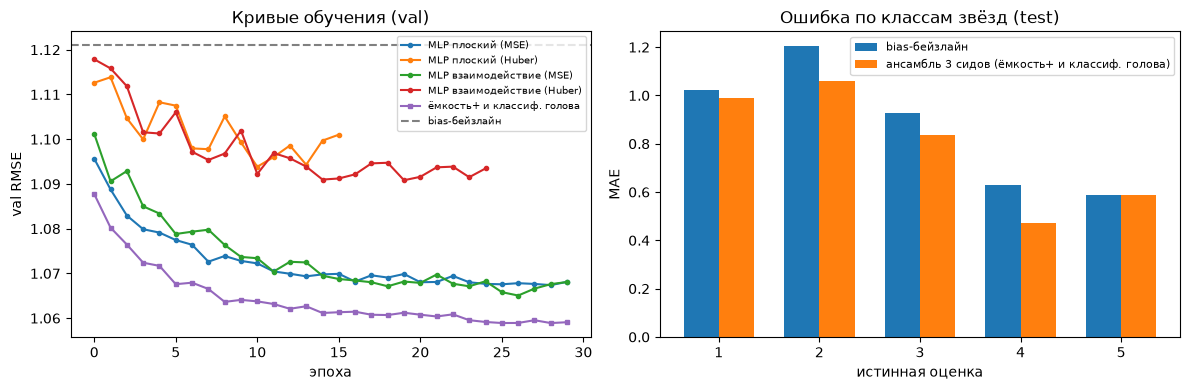

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, r in runs.items():
    axes[0].plot(r["history"]["epoch"], r["history"]["val_rmse"], marker="o", ms=3, label=name)
axes[0].plot(arch_runs[best_arch]["history"]["epoch"], arch_runs[best_arch]["history"]["val_rmse"],
             marker="s", ms=3, label=best_arch)
axes[0].axhline(bias_rmse, ls="--", c="gray", label="bias-бейзлайн")
axes[0].set_xlabel("эпоха"); axes[0].set_ylabel("val RMSE"); axes[0].legend(fontsize=7)
axes[0].set_title("Кривые обучения (val)")

p_best = np.clip(final_pred, 1, 5)
stars_axis = [1, 2, 3, 4, 5]
mae_bias = [np.abs(p_bias[y_te == s] - s).mean() for s in stars_axis]
mae_best = [np.abs(p_best[y_te == s] - s).mean() for s in stars_axis]
w = 0.35
axes[1].bar([s - w / 2 for s in stars_axis], mae_bias, w, label="bias-бейзлайн")
axes[1].bar([s + w / 2 for s in stars_axis], mae_best, w, label=final_name)
axes[1].set_xlabel("истинная оценка"); axes[1].set_ylabel("MAE")
axes[1].set_title("Ошибка по классам звёзд (test)"); axes[1].legend(fontsize=8)
plt.tight_layout()
if ENABLE_ARTIFACTS:
    fig.savefig(ARTIFACTS / "task1_model_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
seg_rows = [{"модель": "bias-бейзлайн", **segment_report(p_bias)},
            {"модель": "MLP взаимодействие (MSE)",
             **segment_report(runs["MLP взаимодействие (MSE)"]["test_pred"])},
            {"модель": final_name, **segment_report(final_pred)}]
seg_table = pd.DataFrame(seg_rows)
print("RMSE по сегментам test:")
print(seg_table.round(4).to_string(index=False))
print(f"\nдоли сегментов: warm юзер {warm_user.mean():.1%}, cold юзер {1 - warm_user.mean():.1%}, "
      f"warm заведение {warm_biz.mean():.1%}")

# "процент успеха" в интерпретируемом виде для финальной модели
err = np.abs(p_best - y_te)
print(f"\nИнтерпретируемые метрики ({final_name}):")
print(f"  точное попадание (округление до звезды): {(np.rint(p_best) == y_te).mean():.1%}")
print(f"  ошибка <= 1 звезды: {(err <= 1.0).mean():.1%}")
like_t, like_p = y_te >= 4, p_best >= 4
print(f"  бинарно 'понравится' (порог 4): accuracy {(like_t == like_p).mean():.1%} "
      f"(наивное 'всем нравится' дало бы {like_t.mean():.1%})")

RMSE по сегментам test:
                                       модель    все  warm юзер  cold юзер  warm заведение  cold заведение
                                bias-бейзлайн 1.1210     1.1824     1.0827          1.1446          1.0213
                     MLP взаимодействие (MSE) 1.0547     1.1126     1.0185          1.0774          0.9583
ансамбль 3 сидов (ёмкость+ и классиф. голова) 1.0451     1.1064     1.0068          1.0673          0.9512

доли сегментов: warm юзер 37.4%, cold юзер 62.6%, warm заведение 80.0%

Интерпретируемые метрики (ансамбль 3 сидов (ёмкость+ и классиф. голова)):
  точное попадание (округление до звезды): 52.1%
  ошибка <= 1 звезды: 73.7%
  бинарно 'понравится' (порог 4): accuracy 80.0% (наивное 'всем нравится' дало бы 64.8%)


## 11. Сохранение артефактов и итоги

In [19]:
# чекпойнты сохраняем вместе с машинно-читаемым конфигом — модель восстановима без чтения исходника
model_config = {
    "arch": cfg_best["arch"], "kwargs": cfg_best["kwargs"], "loss_kind": cfg_best["loss"],
    "decode": "softmax_expectation_1to5" if cfg_best["loss"] == "CE" else "identity_clip_1_5",
    "ucols": U_FULL, "bcols": B_FULL, "ccols": C_FULL,
    "n_cat_vocab": N_CAT_VOCAB, "n_city": N_CITY, "maxlen": MAXLEN,
}
torch.save({"config": {**model_config, "seed": SEED},
            "state": arch_runs[best_arch]["state"]},
           ARTIFACTS / "task1_mlp_single_seed42.pt")
torch.save({"config": {**model_config, "seeds": SEEDS_MULTI},
            "states": [m["state"] for m in ens_members]},
           ARTIFACTS / "task1_mlp_final_ensemble.pt")
metrics = {
    "final_model": final_name,
    "final_test_rmse": rmse(y_te, final_pred),
    "single_seed42_val_rmse": arch_runs[best_arch]["val_rmse"],
    "ensemble_val_rmse": ens_val_rmse,
    "model_config": {k: v for k, v in model_config.items() if k != "kwargs"} |
                    {"kwargs": {k: list(v) if isinstance(v, tuple) else v
                                for k, v in cfg_best["kwargs"].items()}},
    "test_rmse": {name: rmse(y_te, r["test_pred"]) for name, r in {**runs, **arch_runs}.items()},
    "test_rmse_bizemb_ablation": rmse(y_te, run_bizemb["test_pred"]),
    "feature_ablation": {r["вариант"]: r["test RMSE"] for r in abl_rows},
    "multiseed_test_rmse": {k: {"mean": float(np.mean(v)), "std": float(np.std(v))}
                            for k, v in multi.items()},
    "cls_head_multiseed_test_rmse": {"mean": float(np.mean(cls_multi)),
                                     "std": float(np.std(cls_multi))},
    "baselines": dict(zip(base_table["модель"], base_table["RMSE"])),
    "segments_final": segment_report(final_pred),
}
json.dump(metrics, open(ARTIFACTS / "task1_model_metrics.json", "w"),
          ensure_ascii=False, indent=2)
print("[ok] сохранено: task1_mlp_single_seed42.pt, task1_mlp_final_ensemble.pt, "
      "task1_model_metrics.json, task1_prior_feats.parquet, task1_prior_scaler.joblib")

[ok] сохранено: task1_mlp_single_seed42.pt, task1_mlp_final_ensemble.pt, task1_model_metrics.json, task1_prior_feats.parquet, task1_prior_scaler.joblib


In [20]:
final_rmse = rmse(y_te, final_pred)
base_no_prior = abl_table.loc[abl_table["вариант"] == "база (без prior)", "test RMSE"].item()
inter_mse = rmse(y_te, runs["MLP взаимодействие (MSE)"]["test_pred"])
inter_gain = np.mean(multi["плоский"]) - np.mean(multi["взаимодействие"])
cls_gain = np.mean(multi["взаимодействие"]) - np.mean(cls_multi)   # обе стороны — по 3 сида
dcn_delta = rmse(y_te, arch_runs["DCN-v2 (3 cross-слоя)"]["test_pred"]) - inter_mse
seg_best = segment_report(final_pred)
print("=" * 74)
print("ИТОГИ")
print("=" * 74)
print(f"1. Финальная модель (по val): {final_name}")
print(f"   test RMSE {final_rmse:.4f} против bias-бейзлайна {bias_rmse:.4f} "
      f"({(bias_rmse - final_rmse) / bias_rmse:+.1%})")
print(f"2. Главный источник прироста — time-aware prior-признаки: "
      f"{base_no_prior - inter_mse:+.4f} RMSE (база {base_no_prior:.4f} -> {inter_mse:.4f})")
print(f"3. Второй источник — классификационная голова с decode-ожиданием: {cls_gain:+.4f} RMSE")
print(f"   (обе стороны по 3 сида, шум ~{max(np.std(cls_multi), np.std(multi['взаимодействие'])):.4f}; "
      f"ёмкость+ и ансамбль добавляют сверху)")
print(f"4. Вклад явного взаимодействия при фиксированном лоссе (3 сида): {inter_gain:+.4f} RMSE")
print(f"   (шум по сидам ~{max(np.std(v) for v in multi.values()):.4f} — "
      f"{'значим' if inter_gain > 2 * max(np.std(v) for v in multi.values()) else 'на грани шума'})")
print(f"5. Негативные результаты (честно): DCN-v2 {dcn_delta:+.4f} RMSE к референсу; "
      f"biz-эмбеддинг {rmse(y_te, run_bizemb['test_pred']) - inter_mse:+.4f}")
print(f"6. Сегменты финальной модели: warm юзер {seg_best['warm юзер']:.4f} | "
      f"cold юзер {seg_best['cold юзер']:.4f} | warm заведение {seg_best['warm заведение']:.4f} | "
      f"cold заведение {seg_best['cold заведение']:.4f}")
print("7. Test — ковидный период с поляризованными оценками; сравнение честно только")
print("   внутри этого сплита, абсолютные цифры с Netflix-style RMSE не сопоставимы.")

ИТОГИ
1. Финальная модель (по val): ансамбль 3 сидов (ёмкость+ и классиф. голова)
   test RMSE 1.0451 против bias-бейзлайна 1.1210 (+6.8%)
2. Главный источник прироста — time-aware prior-признаки: +0.0470 RMSE (база 1.1017 -> 1.0547)
3. Второй источник — классификационная голова с decode-ожиданием: +0.0035 RMSE
   (обе стороны по 3 сида, шум ~0.0018; ёмкость+ и ансамбль добавляют сверху)
4. Вклад явного взаимодействия при фиксированном лоссе (3 сида): +0.0045 RMSE
   (шум по сидам ~0.0013 — значим)
5. Негативные результаты (честно): DCN-v2 +0.0095 RMSE к референсу; biz-эмбеддинг +0.0157
6. Сегменты финальной модели: warm юзер 1.1064 | cold юзер 1.0068 | warm заведение 1.0673 | cold заведение 0.9512
7. Test — ковидный период с поляризованными оценками; сравнение честно только
   внутри этого сплита, абсолютные цифры с Netflix-style RMSE не сопоставимы.


### Чтение результатов

- **Сеть против bias-бейзлайна** — главный тест осмысленности: выигрыш получен из
  нелинейностей, взаимодействий, time-aware признаков и правильной головы (Ridge показал,
  что линейной комбинации недостаточно).
- **Prior-признаки — главный рычаг**: «какой рейтинг был у заведения на момент отзыва» и
  «как юзер оценивал раньше» информативнее статических агрегатов за всю историю. Это
  согласуется с уроком Netflix Prize: динамика baseline-предикторов даёт основной прирост.
- **Классификационная голова** работает, потому что распределение оценок бимодально —
  регрессия одним нейроном вынуждена отвечать «серединой», softmax может сказать
  «либо 1, либо 5» и усреднить честно.
- **Interaction против Flat при фиксированном лоссе** — корректная проверка вывода Rendle et al.;
  дельта мала, поэтому репортится по трём сидам со стандартным отклонением.
- **Негативные результаты задокументированы**: DCN-v2 на ~30 признаках не окупается,
  biz-эмбеддинг проигрывает prior-признакам заведения (`b_prior_mean` уже несёт его сигнал).
- **Cold против warm** — контентная модель держит небольшой разрыв между сегментами; это её
  главное преимущество и причина отказа от ID-эмбеддингов.

Дальнейшие шаги (этап 2): признаки Задачи 2 (тональность/аспекты текста) как вход рекомендателя,
порядковая голова CORAL как альтернатива decode-ожиданию, пересчёт статических агрегатов только
по train-окну.